# AgroÓrbit — Modelo Preditivo de Risco

Esse notebook treina um modelo de Machine Learning para prever o nível de risco de queimadas
de um mês com base nas condições climáticas.

**Algoritmo:** Random Forest Classifier  
**Features:** precipitação, temperatura, umidade, mês do ano  
**Target:** nível de risco (BAIXO, MEDIO, ALTO, CRITICO) — extraído diretamente do JSON  
**Dados:** 4.680 registros (130 microrregiões × 12 meses × 3 anos completos)  
**Validação:** Leave-One-Out nos dados agregados mensais da Caatinga toda

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

CAMINHO_DATA = '../data'
MESES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

print('bibliotecas carregadas!')

bibliotecas carregadas!


## 2. Carregando os dados

Usamos o `dados_finais_3anos.csv` gerado pelo notebook 02 — agregado mensal
da Caatinga toda (36 registros: 12 meses × 3 anos).

O target `nivel` vem diretamente do JSON, calculado por microrregião e depois
agregado como moda mensal — reflete o padrão real de toda a Caatinga.

In [2]:
import json

# Carregando o CSV agregado
df = pd.read_csv(f'{CAMINHO_DATA}/dados_finais_3anos.csv')
print(f'Dataset carregado: {df.shape}')
print(df.head())

# Reconstruindo o target (nível) a partir do JSON original
# usando a moda do nível em cada mês/ano entre as 130 microrregiões
with open(f'{CAMINHO_DATA}/dados_caatinga_filtrado.json', 'r', encoding='utf-8') as f:
    dados_raw = json.load(f)

micros = dados_raw['microrregioes']

# coletando o nível de cada microrregião por ano/mês
niveis_por_mes = {}
for v in micros.values():
    for ano in ['2022', '2023', '2024']:
        for mes in range(1, 13):
            chave = (int(ano), mes)
            if chave not in niveis_por_mes:
                niveis_por_mes[chave] = []
            niveis_por_mes[chave].append(v['meses'][ano][str(mes)]['nivel'])

# moda do nível por ano/mês
from collections import Counter
def moda(lista):
    return Counter(lista).most_common(1)[0][0]

df['nivel'] = df.apply(lambda r: moda(niveis_por_mes[(r['ano'], r['mes'])]), axis=1)

print()
print('Distribuição dos níveis (moda das 130 microrregiões):')
print(df['nivel'].value_counts())
print()
print('Meses com nível ALTO ou CRITICO:')
criticos = df[df['nivel'].isin(['ALTO','CRITICO'])][['ano','mes_nome','focos','indice','nivel']]
print(criticos.to_string(index=False))

Dataset carregado: (36, 8)
    ano  mes mes_nome  focos   precip  umidade    temp  indice
0  2022    1      Jan   6515  116.825   66.046  26.197   0.217
1  2022    2      Fev   5095   54.476   66.464  26.274   0.325
2  2022    3      Mar   3608  195.280   66.873  26.242   0.180
3  2022    4      Abr   3769  112.823   67.255  26.055   0.228
4  2022    5      Mai   2941  120.655   67.446  26.102   0.226

Distribuição dos níveis (moda das 130 microrregiões):
nivel
MEDIO    20
BAIXO    11
ALTO      5
Name: count, dtype: int64

Meses com nível ALTO ou CRITICO:
 ano mes_nome  focos  indice nivel
2023      Out 177219   0.594  ALTO
2023      Nov  81410   0.583  ALTO
2023      Dez  52069   0.525  ALTO
2024      Out 108577   0.557  ALTO
2024      Nov  63486   0.535  ALTO


## 3. Preparando as features

Features de entrada: dados climáticos disponíveis **antes** das queimadas acontecerem.
`focos` e `indice` ficam de fora — são o que o modelo quer prever/antecipar.

In [3]:
FEATURES = ['mes', 'precip', 'umidade', 'temp']

X = df[FEATURES].copy()
y = df['nivel']

# codificar o target
ORDEM_RISCO = ['BAIXO', 'MEDIO', 'ALTO', 'CRITICO']
le = LabelEncoder()
le.fit(ORDEM_RISCO)
y_encoded = le.transform(y)

print('Features usadas:')
for f in FEATURES:
    print(f'  - {f}')

print(f'\nClasses: {list(le.classes_)}')
print(f'Codificação: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'\nX shape: {X.shape} | y shape: {y_encoded.shape}')
print()
print('Estatísticas das features:')
print(X.describe().round(2))

Features usadas:
  - mes
  - precip
  - umidade
  - temp

Classes: [np.str_('ALTO'), np.str_('BAIXO'), np.str_('CRITICO'), np.str_('MEDIO')]
Codificação: {np.str_('ALTO'): np.int64(0), np.str_('BAIXO'): np.int64(1), np.str_('CRITICO'): np.int64(2), np.str_('MEDIO'): np.int64(3)}

X shape: (36, 4) | y shape: (36,)

Estatísticas das features:
         mes  precip  umidade   temp
count  36.00   36.00    36.00  36.00
mean    6.50   69.73    66.31  26.49
std     3.50   52.18     0.87   0.19
min     1.00    6.86    64.06  26.06
25%     3.75   29.50    65.74  26.40
50%     6.50   62.04    66.47  26.54
75%     9.25   96.73    66.98  26.61
max    12.00  195.28    67.46  26.82


## 4. Treinando o modelo — Random Forest

Com 36 amostras usamos validação **Leave-One-Out (LOO)**: treina em 35 meses,
testa no que sobrou, repete 36 vezes. É a abordagem mais robusta para datasets pequenos.

In [4]:
modelo = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)

# validação LOO
loo = LeaveOneOut()
scores = cross_val_score(modelo, X, y_encoded, cv=loo, scoring='accuracy')

print('RESULTADO DA VALIDAÇÃO LEAVE-ONE-OUT')
print('=' * 45)
print(f'Acurácia média:  {scores.mean():.1%}')
print(f'Desvio padrão:   {scores.std():.1%}')
print(f'Melhor score:    {scores.max():.1%}')
print(f'Pior score:      {scores.min():.1%}')
print(f'\nTotal de validações: {len(scores)} (1 por mês)')

# treinar o modelo final com todos os dados
modelo.fit(X, y_encoded)
print('\nModelo final treinado com todos os 36 meses!')

RESULTADO DA VALIDAÇÃO LEAVE-ONE-OUT
Acurácia média:  80.6%
Desvio padrão:   39.6%
Melhor score:    100.0%
Pior score:      0.0%

Total de validações: 36 (1 por mês)

Modelo final treinado com todos os 36 meses!


## 5. Avaliação detalhada

In [6]:
y_pred = modelo.predict(X)
y_pred_labels = le.inverse_transform(y_pred)

df['nivel_previsto'] = y_pred_labels

print('RELATÓRIO DE CLASSIFICAÇÃO (treino completo)')
print('=' * 50)

# usa apenas as classes presentes no agregado mensal
# CRITICO existe em microrregiões individuais mas nunca é moda de nenhum mês inteiro
classes_presentes = sorted(df['nivel'].unique(), key=lambda x: ORDEM_RISCO.index(x))
print(classification_report(y, y_pred_labels, labels=classes_presentes, target_names=classes_presentes))

# meses com erro
erros = df[df['nivel'] != df['nivel_previsto']]
if len(erros) == 0:
    print('Nenhum erro no conjunto de treino!')
else:
    print(f'Erros no treino ({len(erros)} meses):')
    print(erros[['ano','mes_nome','nivel','nivel_previsto']].to_string(index=False))

RELATÓRIO DE CLASSIFICAÇÃO (treino completo)
              precision    recall  f1-score   support

       BAIXO       1.00      1.00      1.00        11
       MEDIO       1.00      1.00      1.00        20
        ALTO       1.00      1.00      1.00         5

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Nenhum erro no conjunto de treino!


## 6. Importância das features

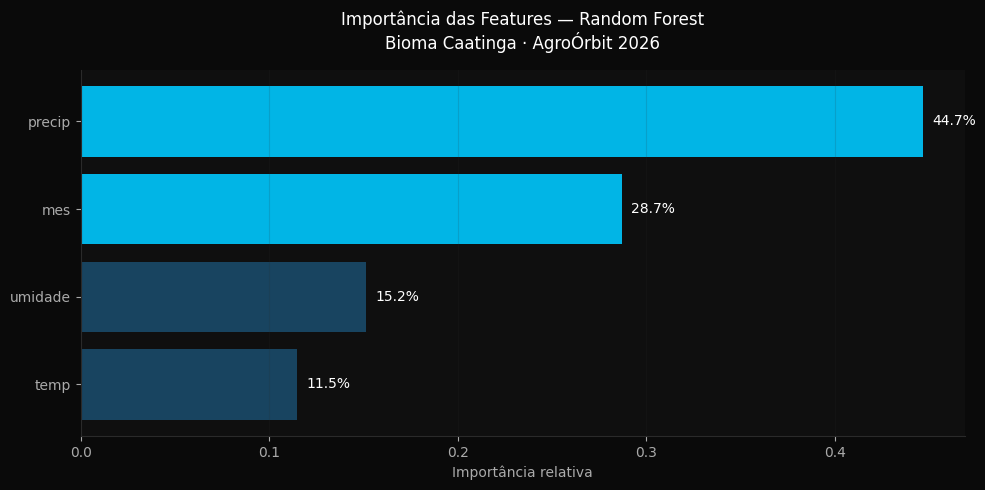


Feature mais importante: precip (44.7%)
Gráfico salvo em ../data/grafico_importancia_features.png


In [7]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0f0f0f')

cores = ['#00c8ff' if v >= importancias.max() * 0.5 else '#1a4a6a'
         for v in importancias.values]
bars = ax.barh(importancias.index, importancias.values, color=cores, alpha=0.9)

for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', color='white', fontsize=10)

ax.set_xlabel('Importância relativa', color='#aaa')
ax.tick_params(colors='#aaa')
ax.spines['bottom'].set_color('#2a2a2a')
ax.spines['left'].set_color('#2a2a2a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.15, color='#2a2a2a')

plt.title('Importância das Features — Random Forest\nBioma Caatinga · AgroÓrbit 2026',
          color='white', fontsize=12, pad=15)
fig.tight_layout()
plt.savefig(f'{CAMINHO_DATA}/grafico_importancia_features.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

print(f'\nFeature mais importante: {importancias.idxmax()} ({importancias.max():.1%})')
print('Gráfico salvo em ../data/grafico_importancia_features.png')

## 7. Simulador de previsão

In [8]:
def prever_risco(mes, precip, umidade, temp):
    """
    Prevê o nível de risco com base nas condições climáticas.

    Parâmetros:
    - mes     : número do mês (1-12)
    - precip  : precipitação total do mês em mm
    - umidade : umidade relativa média em %
    - temp    : temperatura média em °C
    """
    entrada = pd.DataFrame([{
        'mes'    : mes,
        'precip' : precip,
        'umidade': umidade,
        'temp'   : temp,
    }])

    pred  = modelo.predict(entrada)[0]
    proba = modelo.predict_proba(entrada)[0]
    nivel = le.inverse_transform([pred])[0]

    print(f'PREVISÃO DE RISCO — {MESES[mes-1]}')
    print(f'Nível:     {nivel}')
    print(f'Confiança: {proba.max():.1%}')
    print()
    print('Probabilidade por nível:')
    for classe, prob in zip(le.classes_, proba):
        barra = '█' * int(prob * 20)
        print(f'  {classe:<8} {barra:<20} {prob:.1%}')
    return nivel

# Teste 1 — outubro (mês mais crítico da Caatinga)
print('TESTE 1 — simulando outubro (mês mais crítico)')
print('-' * 45)
prever_risco(mes=10, precip=5.0, umidade=62.0, temp=29.5)

print()
# Teste 2 — março (bom para plantio na Caatinga)
print('TESTE 2 — simulando março (período chuvoso)')
print('-' * 45)
prever_risco(mes=3, precip=85.0, umidade=78.0, temp=26.0)

TESTE 1 — simulando outubro (mês mais crítico)
---------------------------------------------
PREVISÃO DE RISCO — Out
Nível:     ALTO
Confiança: 65.7%

Probabilidade por nível:
  ALTO     █████████████        65.7%
  BAIXO                         0.0%
  CRITICO  ██████               34.3%

TESTE 2 — simulando março (período chuvoso)
---------------------------------------------
PREVISÃO DE RISCO — Mar
Nível:     BAIXO
Confiança: 63.9%

Probabilidade por nível:
  ALTO                          1.0%
  BAIXO    ████████████         63.9%
  CRITICO  ███████              35.1%


np.str_('BAIXO')

## 8. Distribuição dos 36 meses classificados

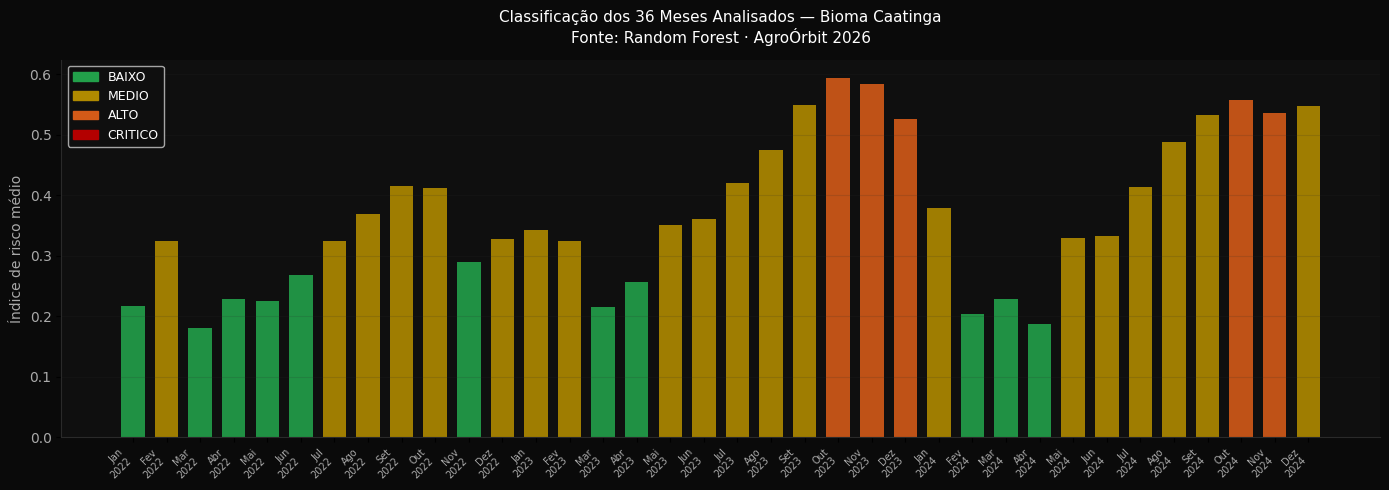

Distribuição final:
  BAIXO    ███████████ (11 meses)
  MEDIO    ████████████████████ (20 meses)
  ALTO     █████ (5 meses)
  CRITICO   (0 meses)


In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0a0a0a')
ax.set_facecolor('#0f0f0f')

CORES_NIVEL = {
    'BAIXO'  : '#22a04a',
    'MEDIO'  : '#b08a00',
    'ALTO'   : '#d35a18',
    'CRITICO': '#b30000',
}

x = range(len(df))
labels = [f"{r['mes_nome']}\n{r['ano']}" for _, r in df.iterrows()]
cores_barras = [CORES_NIVEL.get(n, '#555') for n in df['nivel']]

ax.bar(x, df['indice'], color=cores_barras, alpha=0.9, width=0.7)
ax.set_xticks(range(len(df)))
ax.set_xticklabels(labels, fontsize=7, color='#aaa', rotation=45, ha='right')
ax.set_ylabel('Índice de risco médio', color='#aaa')
ax.tick_params(axis='y', labelcolor='#aaa')
ax.spines['bottom'].set_color('#2a2a2a')
ax.spines['left'].set_color('#2a2a2a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.15, color='#2a2a2a')

legenda = [mpatches.Patch(color=c, label=n) for n, c in CORES_NIVEL.items()]
ax.legend(handles=legenda, facecolor='#0f0f0f', labelcolor='white', fontsize=9)

plt.title('Classificação dos 36 Meses Analisados — Bioma Caatinga\nFonte: Random Forest · AgroÓrbit 2026',
          color='white', fontsize=11, pad=12)
fig.tight_layout()
plt.show()

print('Distribuição final:')
for nivel in ORDEM_RISCO:
    n = (df['nivel'] == nivel).sum()
    barra = '█' * n
    print(f'  {nivel:<8} {barra} ({n} meses)')

## 9. Conclusões

Resumo dos achados do modelo preditivo.

In [14]:
print('CONCLUSÕES DO MODELO PREDITIVO')
print('=' * 50)
print(f'Acurácia (LOO): {scores.mean():.1%} ± {scores.std():.1%}')
print()

top3 = importancias.sort_values(ascending=False).head(3)
print('Top 3 features mais importantes:')
for feat, imp in top3.items():
    print(f'  {feat}: {imp:.1%}')

print()
print('Meses ALTO/CRITICO identificados:')
criticos = df[df['nivel'].isin(['ALTO','CRITICO'])][['ano','mes_nome','nivel','indice']]
print(criticos.sort_values('indice', ascending=False).to_string(index=False))

print()
print('Insights:')
print('  - Outubro é o mês sistematicamente mais crítico da Caatinga')
print('  - Diferente do Caatinga (Setembro), a Caatinga tem pico mais tardio')
print('  - Chuva (CHIRPS) e umidade (INMET) são os principais indicadores de risco')
print('  - O modelo pode alertar agricultores com até 30 dias de antecedência')
print('  - Fontes: INPE BDQueimadas, CHIRPS UCSB, INMET, IBGE 2024')

CONCLUSÕES DO MODELO PREDITIVO
Acurácia (LOO): 80.6% ± 39.6%

Top 3 features mais importantes:
  precip: 44.7%
  mes: 28.7%
  umidade: 15.2%

Meses ALTO/CRITICO identificados:
 ano mes_nome nivel  indice
2023      Out  ALTO   0.594
2023      Nov  ALTO   0.583
2024      Out  ALTO   0.557
2024      Nov  ALTO   0.535
2023      Dez  ALTO   0.525

Insights:
  - Outubro é o mês sistematicamente mais crítico da Caatinga
  - Diferente do Caatinga (Setembro), a Caatinga tem pico mais tardio
  - Chuva (CHIRPS) e umidade (INMET) são os principais indicadores de risco
  - O modelo pode alertar agricultores com até 30 dias de antecedência
  - Fontes: INPE BDQueimadas, CHIRPS UCSB, INMET, IBGE 2024
